## **Import & Setup**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

## **Load the Data**

In [18]:
# Business count per neighbourhood (column sums of the full interaction matrix)
matrix = pd.read_parquet('../data/interaction_matrix_raw.parquet')
nbhd_business = matrix.sum(axis=0)

In [ ]:
PATH_NEIGHBORHOOD_META = 'C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\04. Joining Datasets\\4. Joining Neighborhood - Municipal Community Data\\Extracted CSV Files\\neighborhood_ELSTAT.csv'

In [21]:
# Neighbourhood -> community mapping (from the raw enriched file or the merged one)
df = pd.read_csv(PATH_NEIGHBORHOOD_META)
meta = pd.read_csv(PATH_NEIGHBORHOOD_META)[['Neighborhood', 'Municipal Community']]
nbhd_to_comm = meta.set_index('Neighborhood')['Municipal Community']

In [22]:
# Safety: confirm names align
missing = set(nbhd_business.index) - set(nbhd_to_comm.index)
assert not missing, f'Unmapped neighbourhoods: {missing}'

## **Community Concentration Analysis**

I want to see if the majority of the businesses in concentrated in one community --> no differential power

In [24]:
# Aggregate businesses to the community level
comm_business = nbhd_business.groupby(nbhd_to_comm).sum().sort_values(ascending=False)
total = comm_business.sum()

print(f'Total businesses: {int(total)}')
print(f'Communities with any businesses: {(comm_business > 0).sum()} / {len(comm_business)}\n')

Total businesses: 3882
Communities with any businesses: 17 / 22



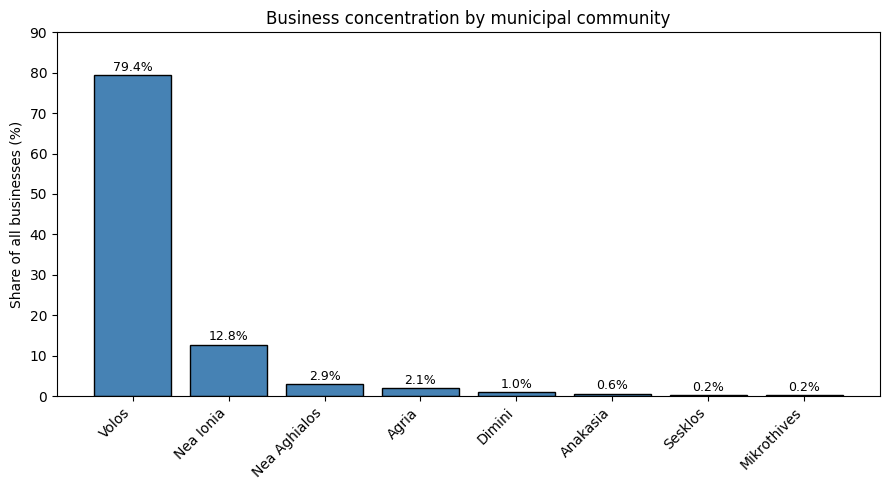

In [25]:
shares = (comm_business / total * 100)
top = shares.head(8)
labels = [c.replace('Municipal Community of ', '') for c in top.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(top)), top.values, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(top)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Share of all businesses (%)')
ax.set_title('Business concentration by municipal community')
for i, v in enumerate(top.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_ylim(0, 90)
plt.tight_layout()
plt.savefig('../results/community_concentration.png', dpi=100, bbox_inches='tight')
plt.show()

## **Build Clean Feature Table**

In [26]:
drop_cols = ['Unnamed: 0', 'Geometry', 'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΣ',
             'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ', 'Area_km2']  # coarse unit-area duplicate
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [28]:
# Neighbourhood-level — fully discriminative; the workhorses for preference queries
GEOGRAPHIC_FEATURES = [
    'distance_to_volos_center_km',
    'distance_to_volos_port_km',
    'dist_to_university_km',
    'dist_to_bus_stop_km',
    'dist_to_main_road_km',
    'Neighborhood_Area_km2',
]

# Community-level — coarse; identical across the 18 Volos-core neighbourhoods.
# Use only for community-scale / peripheral queries, not core discrimination.
COMMUNITY_FEATURES = [
    'Population',
    'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct', 'Διαζευγμένοι_pct',
    'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct',
    'low_education_pct', 'medium_education_pct', 'high_education_pct',
    'unemployment_rate', 'labor_force_participation_rate',
    'primary_sector_pct', 'secondary_sector_pct', 'tertiary_sector_pct',
]

In [29]:
df = df.set_index('Neighborhood')
df.to_parquet('../data/neighborhood_features.parquet')

In [ ]:
# Quick verification of the coarseness point: community features should be
# constant within a community. Confirm for the Volos core.
volos = df[df['Municipal Community'] == 'Municipal Community of Volos']
print(f'Volos-core neighbourhoods: {len(volos)}')
print('Unique values of a community feature across them (should be 1):',
      volos['Population'].nunique())
print('Unique values of a geographic feature across them (should be many):',
      volos['distance_to_volos_center_km'].nunique())

Volos-core neighbourhoods: 18
Unique values of a community feature across them (should be 1): 1
Unique values of a geographic feature across them (should be many): 18


: 